In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

import itertools

D = 1

N = 20000
L = 3.*np.pi

N_f = 4*N
L_f = 4*L

grid_dims = [N for _ in range(D)]
grid_dims_f = [N_f for _ in range(D)]

phys_dims = [L for _ in range(D)]
phys_dims_f = [L_f for _ in range(D)]

twopi = 2.*np.pi

dk_f = twopi/L_f
dk = twopi/L

dx_f = L_f/N_f
dx = L/N

BREAK = N//200

In [2]:
f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims, (-1., -5./3.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': 0.5})
f = f_f[N_f//2-N//2:N_f//2+N//2]
f = f - np.mean(f)

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:105: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)


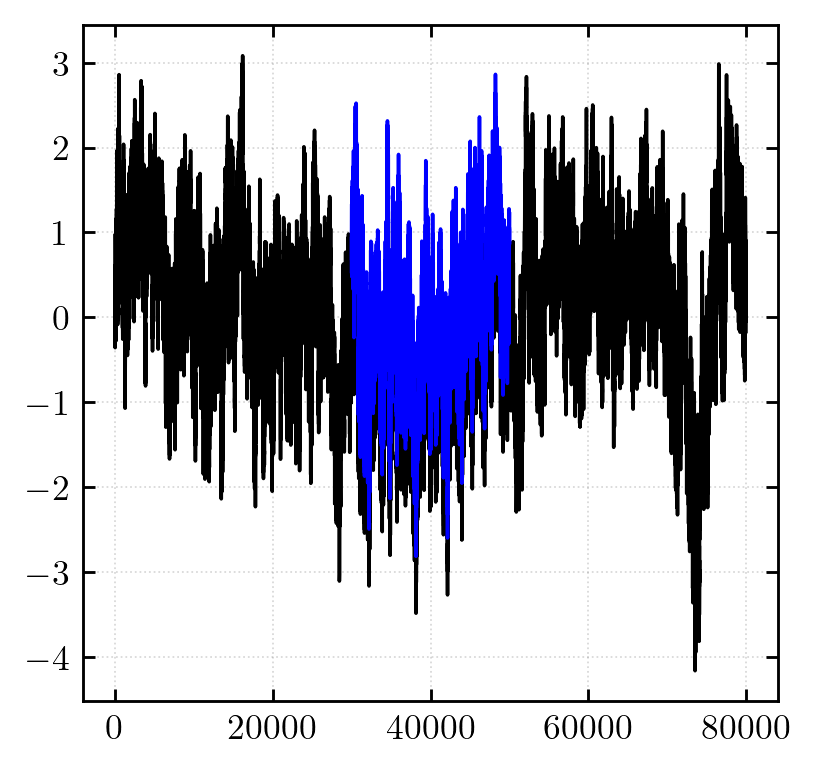

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
ax.plot(f_f, linewidth=1., color='black')
ax.plot(np.arange(N_f//2-N//2, N_f//2+N//2), f, linewidth=1., color='blue')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

Text(0.5, 0, '$\\lambda$')

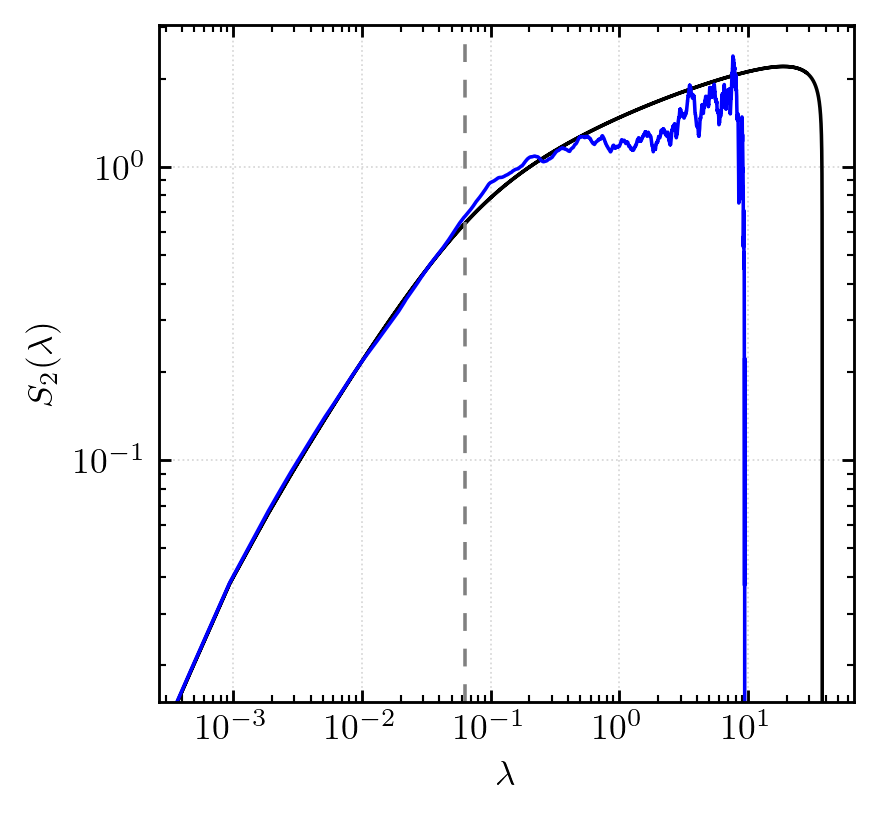

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lv_f = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims_f])
sf_f = strfn.process_lags(f_f, f_f, lv_f, lenn=phys_dims_f, shape=[2*n+1 for n in grid_dims_f], orders=[2], periodic=True)[0]
lvm_f = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims_f]) * dx
lvm_f = lvm_f[N:]
sf_f = sf_f[N:]
ax.loglog(lvm_f, sf_f, linewidth=1., color='black')

lv = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf = strfn.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=False)[0]
lvm = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
lvm = lvm[N:]
sf = sf[N:]
ax.loglog(lvm, sf, linewidth=1., color='blue')

ax.axvline(2.*np.pi/BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$S_2(\lambda)$')
ax.set_xlabel(r'$\lambda$')

Text(0.5, 0, 'Wavenumber, $k$')

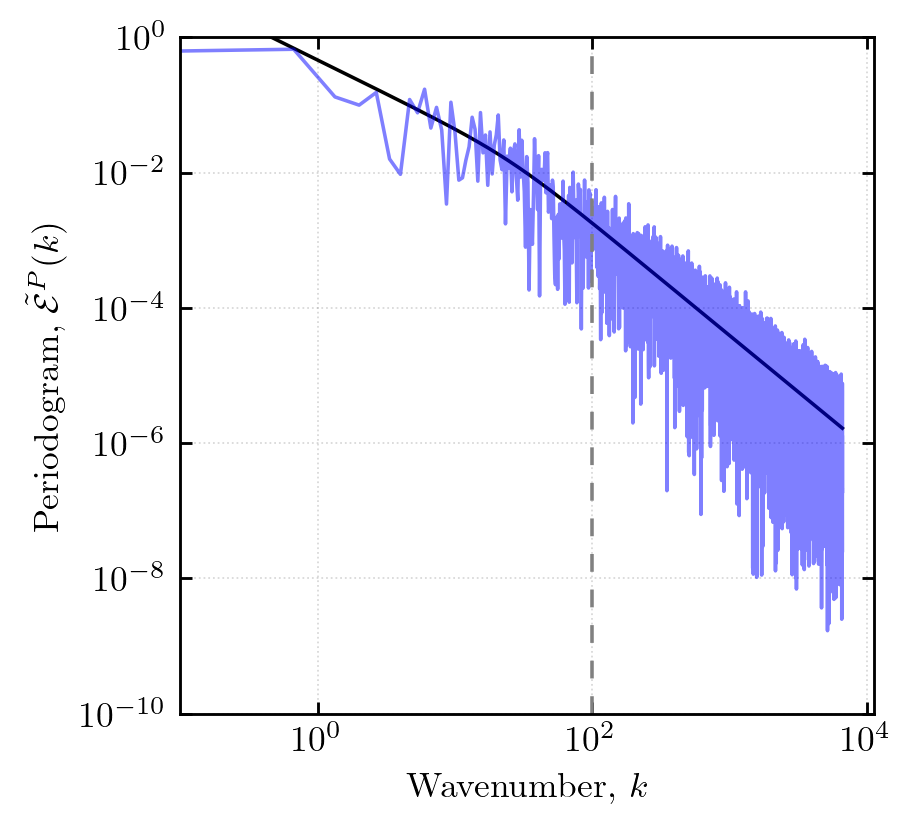

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

kD_f, fekD_f = per_spectra.modal_spectrum(f_f, phys_dims=phys_dims_f)
kD_f, fekD_f = kD_f[0][N_f//2:], fekD_f[N_f//2:]
ax.loglog(kD_f, fekD_f, color='black', linewidth=1.)

kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
kD, fekD = kD[0][N//2:], fekD[N//2:]
ax.loglog(kD, fekD, color='blue', linewidth=1., alpha=0.5)

ax.axvline(BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_ylim((1e-10, 1e0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k$')

In [6]:
def omni_spectrum_2(ell, sf2, phys_dims, grid_dims):
    dS = np.gradient(sf2, dx)
    dell = np.gradient(ell, dx)
    fek = (ell)**2 * (dS) * (twopi**D / 4.) / (twopi)
    #kk = 1. / ell
    kk = twopi / ell
    return kk[::-1], fek[::-1]

def omni_spectrum(ell, sf2, phys_dims, grid_dims):
    #kk = 1. / ell
    kk = twopi / ell
    fek = (twopi**D / 4.) * sf2 * ell / (twopi)
    return kk[::-1], fek[::-1]

l, s = omni_spectrum(lvm, sf, phys_dims, grid_dims)
l2, s2 = omni_spectrum_2(lvm, sf, phys_dims, grid_dims)

l_f, s_f = omni_spectrum(lvm_f, sf_f, phys_dims_f, grid_dims_f)

/tmp/ipykernel_20121/2585309703.py:11: RuntimeWarning: divide by zero encountered in true_divide
  kk = twopi / ell
/tmp/ipykernel_20121/2585309703.py:6: RuntimeWarning: divide by zero encountered in true_divide
  kk = twopi / ell


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'Wavenumber, $k$')

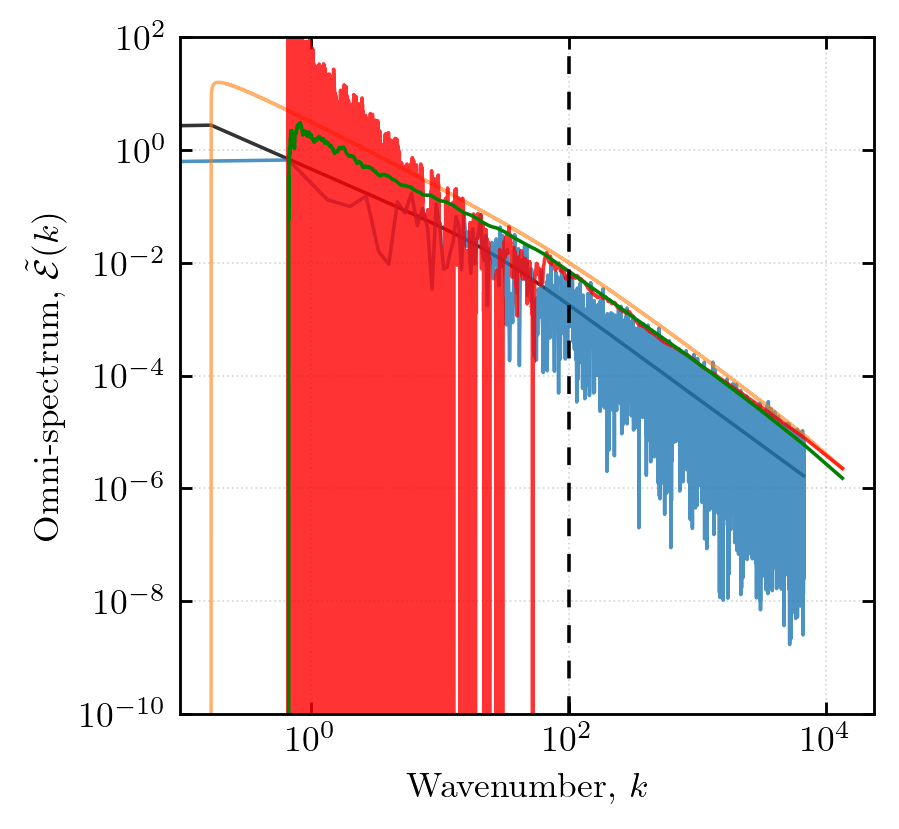

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.loglog(kD_f, fekD_f, linewidth=1., alpha=0.8, color='black')

ax.loglog(kD, fekD, linewidth=1., alpha=0.8)

ax.loglog(l_f, s_f, linewidth=1., alpha=0.6)

ax.loglog(l2, s2, linewidth=1., color='red', alpha=0.8)
ax.loglog(l, s * (2./3.), linewidth=1., color='green')

ax.axvline(BREAK, color='black', linestyle=(0,(5,5)), linewidth=1.)
ax.set_ylim((1e-10, 1e2))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=False, fancybox=False)

ax.set_ylabel(r'Omni-spectrum, $\tilde{\mathcal{E}}(k)$')
ax.set_xlabel(r'Wavenumber, $k$')